# 🏦 Bank Loan Analysis — End-to-End Data Analyst Project

## Project Objective
Analyze a bank loan portfolio using Python to understand lending activity, portfolio composition, loan performance, borrower segments, and observed risk patterns.

# 1. Problem Understanding

## 1.1 Business Context

Bank loan data can be used to monitor lending activity, borrower characteristics, loan performance, repayment behavior, portfolio concentration, and credit risk.

The supplied Business Requirement Document (BRD) asks for portfolio KPIs, Good vs Bad Loan KPIs, and analysis by Issue Month, State, Loan Term, Employment Length, Loan Purpose, and Home Ownership.

## 1.2 Business Questions

1. How large is the loan portfolio in the available data?
2. How much has been funded and how much is represented by total loan-level payment?
3. What are the average interest rate and DTI?
4. What proportion of loans are classified as Good vs Bad under the documented analytical rule?
5. How has loan origination activity changed over time?
6. Which states, purposes, terms, employment groups, and home-ownership categories represent the largest activity?
7. How does observed loan performance differ across Grade and Sub Grade?
8. Does observed performance differ by loan term, purpose, state, home ownership, and verification status?
9. How does DTI differ across loan outcomes?
10. What patterns should the business monitor further?


# 2. Data Loading & Inspection

## 2.1 Import Libraries

The imports are kept focused on the work required in this project:

- **Pandas** — tabular data loading, cleaning, transformation, aggregation
- **NumPy** — conditional logic and numerical operations
- **Matplotlib** — static visualizations
- **Seaborn** — analytical/statistical visualizations
- **Plotly Express** — optional interactive exploration


In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Optional interactive visualization
import plotly.express as px

# Warning management
import warnings

# Keep notebook output readable during development.
warnings.filterwarnings("ignore")

# Display settings for easier inspection.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Consistent plotting defaults.
sns.set_theme(style="whitegrid")

## 2.2 Load the Dataset

The bank loan dataset is stored in the `Data` folder and loaded using Pandas.

In [2]:
# Load the bank loan dataset from the Excel file.

df = pd.read_excel("Data/financial_loan.xlsx")

In [3]:
# Display the dataset dimensions.

print("Dataset Shape:", df.shape)

Dataset Shape: (38576, 24)


## 2.3 Sample Records


In [4]:
# Inspect the first few records to understand the structure and values.

df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,Charged Off,2021-05-13,1314167,car,C4,60 months,Source Verified,"30,000.00",0.01,59.83,0.15,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1288686,car,E1,36 months,Source Verified,"48,000.00",0.05,109.43,0.19,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,Charged Off,2021-02-09,1304116,car,C5,36 months,Not Verified,"50,000.00",0.21,421.65,0.16,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,Fully Paid,2021-04-12,1272024,car,B2,60 months,Source Verified,"42,000.00",0.05,97.06,0.11,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,1302971,car,A1,36 months,Verified,"83,000.00",0.02,106.53,0.06,3500,28,3835


In [5]:
# Inspect the last few records to make sure the file was loaded completely.

df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,member_id,purpose,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,Current,2021-06-16,992381,wedding,C1,60 months,Verified,"100,000.00",0.20,551.64,0.13,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,Current,2021-06-16,1192039,wedding,C1,60 months,Verified,"50,000.00",0.05,579.72,0.13,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,Current,2021-06-16,1089898,wedding,D5,60 months,Verified,"65,000.00",0.17,627.93,0.17,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,Current,2021-06-16,1194971,wedding,D5,60 months,Verified,"368,000.00",0.00,612.72,0.18,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,Current,2021-06-16,872217,wedding,F3,60 months,Verified,"80,000.00",0.06,486.86,0.21,18000,7,27679


## 2.4 Dataset Dimensions


In [6]:
# Report dataset size in rows and columns.

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38576
Number of columns: 24


## 2.5 Column Structure


In [7]:
# List all fields available for business and technical analysis.

df.columns.tolist()

['id',
 'address_state',
 'application_type',
 'emp_length',
 'emp_title',
 'grade',
 'home_ownership',
 'issue_date',
 'last_credit_pull_date',
 'last_payment_date',
 'loan_status',
 'next_payment_date',
 'member_id',
 'purpose',
 'sub_grade',
 'term',
 'verification_status',
 'annual_income',
 'dti',
 'installment',
 'int_rate',
 'loan_amount',
 'total_acc',
 'total_payment']

## 2.6 Data Types and Non-Null Counts


In [8]:
# info() shows data types, non-null counts, and memory usage.
# This is the first structural check before any cleaning is performed.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

## 2.7 Descriptive Statistics


In [9]:
# Summarize numeric fields to understand central tendency, spread,
# minimum/maximum values, and potential unusual observations.

df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,"38,576.00","681,037.06","54,734.00","513,517.00","662,728.00","836,506.00","1,077,501.00","211,324.58"
issue_date,38576,2021-07-16 02:31:35.562007,2021-01-01 00:00:00,2021-04-11 00:00:00,2021-07-11 00:00:00,2021-10-11 00:00:00,2021-12-12 00:00:00,NaN
last_credit_pull_date,38576,2021-06-08 13:36:34.193280,2021-01-08 00:00:00,2021-04-15 00:00:00,2021-05-16 00:00:00,2021-08-13 00:00:00,2022-01-20 00:00:00,NaN
last_payment_date,38576,2021-06-26 09:52:08.909166,2021-01-08 00:00:00,2021-03-16 00:00:00,2021-06-14 00:00:00,2021-09-15 00:00:00,2021-12-15 00:00:00,NaN
next_payment_date,38576,2021-07-26 20:42:20.605557,2021-02-08 00:00:00,2021-04-16 00:00:00,2021-07-14 00:00:00,2021-10-15 00:00:00,2022-01-15 00:00:00,NaN
member_id,"38,576.00","847,651.51","70,699.00","662,978.75","847,356.50","1,045,652.50","1,314,167.00","266,810.46"
annual_income,"38,576.00","69,644.54","4,000.00","41,500.00","60,000.00","83,200.50","6,000,000.00","64,293.68"
dti,"38,576.00",0.13,0.00,0.08,0.13,0.19,0.30,0.07
installment,"38,576.00",326.86,15.69,168.45,283.05,434.44,"1,305.19",209.09
int_rate,"38,576.00",0.12,0.05,0.09,0.12,0.15,0.25,0.04


# 3. Data Quality Assessment

The goal here is to identify genuine data-quality issues **before** changing the data.


## 3.1 Missing Values


In [10]:
# Count missing values in every column.
missing_summary = df.isna().sum().to_frame("missing_count")

# Convert counts into percentages to understand materiality.
missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
)

# Show only columns containing missing values.
missing_summary = missing_summary.sort_values(
    "missing_count", ascending=False
)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
emp_title,1438,3.73


### Missing-Value Decision

`emp_title` contains missing values. The loan records are retained because the field is not required for the core portfolio KPIs. Dropping the complete loan records would unnecessarily reduce the analytical population.

For occupation-specific analysis, the missing occupation value can be represented as `"Not Available"` without changing the underlying loan record.


In [11]:
# Create a separate reporting-friendly occupation field only when needed.
# The original emp_title column is preserved.

# Create a separate reporting-friendly occupation field when needed.
# The original emp_title column is preserved.
df["emp_title_analysis"] = df["emp_title"].fillna("Not Available")

print("Non-null values in emp_title_analysis:", df["emp_title_analysis"].count())

Non-null values in emp_title_analysis: 38576


**Note:** All 38,576 records are non-null across every column except `emp_title`, which contains 37,138 non-null values and 1,438 missing values (3.73%). This is consistent with the missing-value assessment above. The derived `emp_title_analysis` field contains 38,576 non-null values because missing employer titles are represented as `"Not Available"` for analysis when required.

## 3.2 Duplicate Assessment


In [12]:
# Check complete duplicate rows and key identifiers separately.

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Loan IDs:", df["id"].duplicated().sum())
print("Duplicate Member IDs:", df["member_id"].duplicated().sum())

Duplicate rows: 0
Duplicate Loan IDs: 0
Duplicate Member IDs: 0


## 3.3 Unique-Value Assessment


In [13]:
# Review cardinality to distinguish identifiers from categorical dimensions.

df.nunique().sort_values()

application_type             1
term                         2
loan_status                  3
verification_status          3
home_ownership               5
grade                        7
emp_length                  11
purpose                     14
sub_grade                   35
address_state               50
issue_date                  65
total_acc                   82
last_payment_date          102
next_payment_date          102
last_credit_pull_date      107
int_rate                   371
loan_amount                880
dti                       2863
annual_income             5096
installment              15132
total_payment            19525
emp_title                28525
emp_title_analysis       28526
id                       38576
member_id                38576
dtype: int64

## 3.4 Categorical Value Review


In [14]:
# Inspect the main categorical fields before standardization.
categorical_cols = [
    "application_type",
    "address_state",
    "emp_length",
    "grade",
    "home_ownership",
    "loan_status",
    "purpose",
    "sub_grade",
    "term",
    "verification_status",
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))



--- application_type ---
application_type
INDIVIDUAL    38576
Name: count, dtype: int64

--- address_state ---
address_state
CA    6894
NY    3701
FL    2773
TX    2664
NJ    1822
IL    1486
PA    1482
VA    1375
GA    1355
MA    1310
OH    1188
MD    1027
AZ     833
WA     805
CO     770
NC     759
CT     730
MI     685
MO     660
MN     592
Name: count, dtype: int64

--- emp_length ---
emp_length
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
5 years      3273
1 year       3229
6 years      2228
7 years      1772
8 years      1476
9 years      1255
Name: count, dtype: int64

--- grade ---
grade
B    11674
A     9689
C     7904
D     5182
E     2786
F     1028
G      313
Name: count, dtype: int64

--- home_ownership ---
home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64

--- loan_status ---
loan_status
Fully Paid     32145
Charged Off     5333
Current         109

## 3.5 Date Range Review


In [15]:
# Review date ranges before converting/validating them.

date_cols = [
    "issue_date",
    "last_credit_pull_date",
    "last_payment_date",
    "next_payment_date",
]

for col in date_cols:
    print(
        f"{col}:",
        df[col].min(),
        "to",
        df[col].max()
    )

issue_date: 2021-01-01 00:00:00 to 2021-12-12 00:00:00
last_credit_pull_date: 2021-01-08 00:00:00 to 2022-01-20 00:00:00
last_payment_date: 2021-01-08 00:00:00 to 2021-12-15 00:00:00
next_payment_date: 2021-02-08 00:00:00 to 2022-01-15 00:00:00


## 3.6 Numeric Validation Rules


In [16]:
# Check for impossible or suspicious values using simple domain rules.
# These checks are diagnostic; values are not removed automatically.

validation = pd.Series({
    "loan_amount_<=_0": (df["loan_amount"] <= 0).sum(),
    "negative_interest_rate": (df["int_rate"] < 0).sum(),
    "negative_dti": (df["dti"] < 0).sum(),
    "missing_issue_date": df["issue_date"].isna().sum(),
})

validation

loan_amount_<=_0          0
negative_interest_rate    0
negative_dti              0
missing_issue_date        0
dtype: int64

### 3.7 Data Quality Summary


In [17]:
# Summarize the main data-quality checks completed before cleaning decisions.

data_quality_summary = pd.DataFrame({
    "Check": [
        "Missing emp_title",
        "Duplicate rows",
        "Duplicate Loan IDs",
        "Duplicate Member IDs",
        "Missing issue_date",
        "Non-positive loan_amount",
        "Negative interest rate",
        "Negative DTI",
    ],
    "Result": [
        int(df["emp_title"].isna().sum()),
        int(df.duplicated().sum()),
        int(df["id"].duplicated().sum()),
        int(df["member_id"].duplicated().sum()),
        int(df["issue_date"].isna().sum()),
        int((df["loan_amount"] <= 0).sum()),
        int((df["int_rate"] < 0).sum()),
        int((df["dti"] < 0).sum()),
    ],
})

data_quality_summary

,Check,Result
0,Missing emp_title,1438
1,Duplicate rows,0
2,Duplicate Loan IDs,0
3,Duplicate Member IDs,0
4,Missing issue_date,0
5,Non-positive loan_amount,0
6,Negative interest rate,0
7,Negative DTI,0


# 4. Data Cleaning

Cleaning decisions are intentionally conservative. The goal is to improve consistency without changing valid business observations.

## 4.1 Standardize Text Fields


In [18]:
# Remove accidental leading/trailing whitespace from text fields.
text_cols = [
    "address_state",
    "application_type",
    "emp_length",
    "emp_title",
    "grade",
    "home_ownership",
    "loan_status",
    "purpose",
    "sub_grade",
    "term",
    "verification_status",
]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# Verify term values after whitespace normalization.
print(df["term"].value_counts())

term
36 months    28237
60 months    10339
Name: count, dtype: int64[pyarrow]


## 4.2 Convert / Validate Date Columns


In [19]:
# Convert all date fields to datetime for reliable time analysis.

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Confirm successful conversion.

print(df[date_cols].dtypes)
print("\nMissing dates after conversion:")
print(df[date_cols].isna().sum())

issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
next_payment_date        datetime64[us]
dtype: object

Missing dates after conversion:
issue_date               0
last_credit_pull_date    0
last_payment_date        0
next_payment_date        0
dtype: int64


## 4.3 Missing-Value Decisions

`emp_title` has 1,438 missing values (3.73%). The loan records are retained because employer title is not required for the core BRD analysis and there is no reliable value to impute.

A separate `emp_title_analysis` field is used only when a reporting-friendly label is needed; the original `emp_title` field remains unchanged.


In [20]:
# Preserve the raw employer field and use a reporting-friendly field only when needed.
df["emp_title_analysis"] = df["emp_title"].fillna("Not Available")

print("Original emp_title missing:", df["emp_title"].isna().sum())
print("Reporting label count:", (df["emp_title_analysis"] == "Not Available").sum())

Original emp_title missing: 1438
Reporting label count: 1438


## 4.4 Duplicate Handling

No duplicate rows, Loan IDs, or Member IDs were found, so no records are removed for duplication.


In [21]:
# Confirm that the dataset remains free of duplicate records and identifiers.

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Loan IDs:", df["id"].duplicated().sum())
print("Duplicate Member IDs:", df["member_id"].duplicated().sum())

Duplicate rows: 0
Duplicate Loan IDs: 0
Duplicate Member IDs: 0


## 4.5 Validation After Cleaning


In [22]:
# Validate the cleaned text and date fields.

print("Term values after text cleaning:")
print(df["term"].value_counts())

print("\nDate dtypes after validation:")
print(df[date_cols].dtypes)

print("\nMissing dates after conversion:")
print(df[date_cols].isna().sum())

Term values after text cleaning:
term
36 months    28237
60 months    10339
Name: count, dtype: int64[pyarrow]

Date dtypes after validation:
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
next_payment_date        datetime64[us]
dtype: object

Missing dates after conversion:
issue_date               0
last_credit_pull_date    0
last_payment_date        0
next_payment_date        0
dtype: int64


## 4.6 Final Data-Quality Recheck


In [23]:
# Recheck core quality indicators after cleaning.

quality_check = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_loan_ids": df["id"].duplicated().sum(),
    "missing_emp_title": df["emp_title"].isna().sum(),
    "missing_issue_dates": df["issue_date"].isna().sum(),
})

quality_check

rows                   38576
columns                   25
duplicate_rows             0
duplicate_loan_ids         0
missing_emp_title       1438
missing_issue_dates        0
dtype: int64

# 5. Feature Engineering

Feature engineering creates business-friendly analytical fields while preserving the raw variables.

## Features created

- Issue Year
- Issue Month
- Issue Month Name
- Issue Year-Month
- Interest Rate %
- DTI %
- Good/Bad Loan Category
- Latest Issue Month flag


In [24]:
# Determine the latest available issue date to define the reporting period.
report_date = df["issue_date"].max()

# Create time dimensions for monthly trend analysis.
df["issue_year"] = df["issue_date"].dt.year
df["issue_month"] = df["issue_date"].dt.month
df["issue_month_name"] = df["issue_date"].dt.strftime("%b")
df["issue_year_month"] = df["issue_date"].dt.to_period("M")

# Create presentation-friendly percentage fields.
# Raw int_rate and dti remain unchanged for calculations.
df["interest_rate_pct"] = df["int_rate"] * 100
df["dti_pct"] = df["dti"] * 100

# Define the analytical Good/Bad Loan classification requested by the project.
# This mapping is explicitly documented as an analytical assumption.
df["loan_category"] = np.select(
    [
        df["loan_status"].isin(["Fully Paid", "Current"]),
        df["loan_status"].eq("Charged Off"),
    ],
    [
        "Good Loan",
        "Bad Loan",
    ],
    default="Review",
)

# Flag loans originated during the latest available calendar month.
df["is_latest_issue_month"] = (
    df["issue_year_month"] == report_date.to_period("M")
)

print("Latest available issue date:", report_date.date())
print("\nLoan category distribution:")
print(df["loan_category"].value_counts(dropna=False))

Latest available issue date: 2021-12-12

Loan category distribution:
loan_category
Good Loan    33243
Bad Loan      5333
Name: count, dtype: int64


### 6.Core analysis

## 6.1 Executive Portfolio KPIs

### Business Questions
- How large is the loan portfolio?
- How much was funded and how much loan-level payment is recorded?
- What are the average interest rate and DTI?


In [25]:
# Calculate the core portfolio KPIs from the cleaned loan-level data.

total_applications = df["id"].nunique()
total_funded = df["loan_amount"].sum()
total_received = df["total_payment"].sum()
avg_interest_rate = df["int_rate"].mean() * 100
avg_dti = df["dti"].mean() * 100

def format_dollar_millions(value):
    # Present large financial values in millions with a dollar sign.
    return f"${value / 1_000_000:.2f}M"

def format_dollar_thousands(value):
    # Present medium-sized financial values in thousands with a dollar sign.
    return f"${value / 1_000:.2f}K"

def format_percent(value):
    # Present ratios and rates as percentages.
    return f"{value:.2f}%"

portfolio_kpis = pd.DataFrame({
    "KPI": [
        "Total Loan Applications",
        "Total Funded Amount",
        "Total Amount Received",
        "Avg Int Rate",
        "Avg DTI",
    ],
    "Value": [
        f"{total_applications:,}",
        format_dollar_millions(total_funded),
        format_dollar_millions(total_received),
        format_percent(avg_interest_rate),
        format_percent(avg_dti),
    ],
})

portfolio_kpis

,KPI,Value
0,Total Loan Applications,"38,576"
1,Total Funded Amount,$435.76M
2,Total Amount Received,$473.07M
3,Avg Int Rate,12.05%
4,Avg DTI,13.33%


### Business Interpretation

The portfolio contains **38,576 loans** and approximately **\$435.76M** in funded principal.
The average interest rate is **12.05%** and the average DTI is **13.33%**.
The recorded **\$473.07M** is based on cumulative loan-level `total_payment`, not a transaction-level cash ledger.

## 6.2 MTD KPI Analysis

### Business Questions

* What is the latest available loan issue date?
* How many loan applications were originated during the latest available month-to-date period?
* How much was funded during the latest month-to-date period?
* What loan-level payment amount is recorded for loans originated during the latest month-to-date period?

*Note: The payment metric is a loan-level cumulative payment proxy, not a transaction-level monthly cash-collection measure.*

In [26]:
# Isolate loans originated during the latest available calendar month.
mtd = df[df["is_latest_issue_month"]].copy()

# MTD application and funded-amount metrics are directly supported by Issue Date.
mtd_applications = mtd["id"].nunique()
mtd_funded = mtd["loan_amount"].sum()

# This is intentionally labeled as a proxy because total_payment is cumulative
# at loan level rather than a month-by-month transaction amount.
mtd_payment_proxy = mtd["total_payment"].sum()

mtd_kpis = pd.DataFrame({
    "Metric": [
        "Reporting Date",
        "MTD Loan Applications",
        "MTD Total Funded Amount",
        "MTD Total Amount Received (Loan-Level Proxy)",
    ],
    "Value": [
        report_date.strftime("%d-%b-%Y"),
        f"{mtd_applications:,}",
        format_dollar_millions(mtd_funded),
        format_dollar_millions(mtd_payment_proxy),
    ],
})

mtd_kpis

,Metric,Value
0,Reporting Date,12-Dec-2021
1,MTD Loan Applications,"4,314"
2,MTD Total Funded Amount,$53.98M
3,MTD Total Amount Received (Loan-Level Proxy),$58.07M


### Business Interpretation
The latest observed issue month contains **4,314 applications** and approximately **$53.98M** in funded principal. Because the dataset ends on 12-Dec-2021, these are partial-month figures.


### 6.3 Good vs Bad Loan KPIs
**Business Questions**

* What proportion of the portfolio is classified as Good Loans versus Bad Loans?
* How many Good Loans and Bad Loans are present?
* How much funded amount is associated with Good Loans and Bad Loans?
* What loan-level payment amount is recorded for Good Loans and Bad Loans?

**Analytical rule:**

* Good Loan = Fully Paid + Current
* Bad Loan = Charged Off

In [27]:
# Build Good/Bad portfolio metrics in one reusable summary.

good = df["loan_category"].eq("Good Loan")
bad = df["loan_category"].eq("Bad Loan")

good_bad_summary = pd.DataFrame({
    "Metric": [
        "Good Loan Applications",
        "Good Loan %",
        "Good Loan Funded Amount",
        "Good Loan Total Amount Received",
        "Bad Loan Applications",
        "Bad Loan %",
        "Bad Loan Funded Amount",
        "Bad Loan Total Amount Received",
    ],
    "Value": [
        f"{df.loc[good, 'id'].nunique():,}",
        format_percent(good.mean() * 100),
        format_dollar_millions(df.loc[good, "loan_amount"].sum()),
        format_dollar_millions(df.loc[good, "total_payment"].sum()),
        f"{df.loc[bad, 'id'].nunique():,}",
        format_percent(bad.mean() * 100),
        format_dollar_millions(df.loc[bad, "loan_amount"].sum()),
        format_dollar_millions(df.loc[bad, "total_payment"].sum()),
    ],
})

good_bad_summary


,Metric,Value
0,Good Loan Applications,"33,243"
1,Good Loan %,86.18%
2,Good Loan Funded Amount,$370.22M
3,Good Loan Total Amount Received,$435.79M
4,Bad Loan Applications,"5,333"
5,Bad Loan %,13.82%
6,Bad Loan Funded Amount,$65.53M
7,Bad Loan Total Amount Received,$37.28M


### Visualisation — Good vs Bad Loan Mix


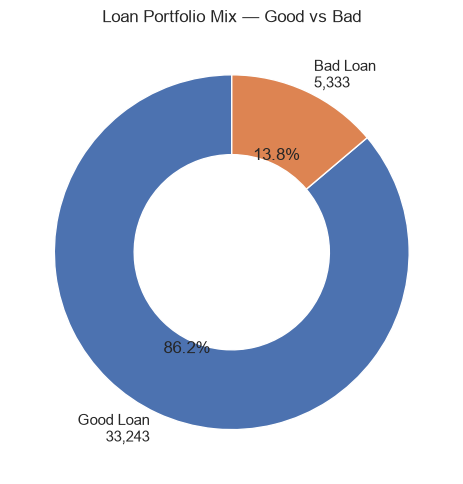

In [28]:
# Visualize the Good vs Bad application mix.
fig, ax = plt.subplots(figsize=(7, 5))

good_bad_counts = pd.Series({
    "Good Loan": int(good.sum()),
    "Bad Loan": int(bad.sum()),
})

ax.pie(
    good_bad_counts.values,
    labels=[f"{k}\n{v:,}" for k, v in good_bad_counts.items()],
    autopct="%.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45},
)

ax.set_title("Loan Portfolio Mix — Good vs Bad")
plt.tight_layout()
plt.show()

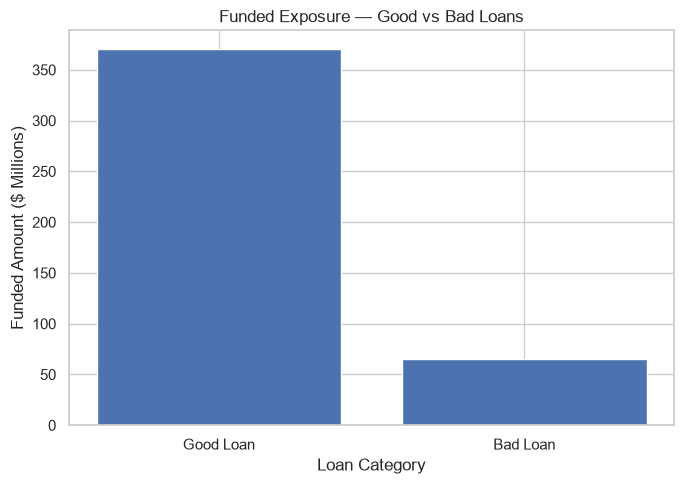

In [29]:
# Compare funded exposure by Good vs Bad classification.

fig, ax = plt.subplots(figsize=(7, 5))
funded_mix = pd.Series({
    "Good Loan": df.loc[good, "loan_amount"].sum() / 1_000_000,
    "Bad Loan": df.loc[bad, "loan_amount"].sum() / 1_000_000,
})

ax.bar(funded_mix.index, funded_mix.values)
ax.set_title("Funded Exposure — Good vs Bad Loans")
ax.set_xlabel("Loan Category")
ax.set_ylabel("Funded Amount ($ Millions)")
plt.tight_layout()
plt.show()

### Business Interpretation
Under the project's analytical mapping, **86.18%** of loans are Good Loans and **13.82%** are Bad Loans. Bad Loans represent approximately **$65.53M** of funded principal. Percentages should always be interpreted together with their underlying application and funded volumes.


### 6.4 Monthly Trends by Issue Date
**Business Questions**

* How does loan application volume change over time?
* How does funded amount change over time?
* How does loan-level payment change over time?
* Which month has the highest observed application volume?
* Which month has the highest observed funded amount?

December is a partial month through **12-Dec-2021**.

In [30]:
# Aggregate the portfolio by Issue Year-Month.
monthly_analysis = (
    df.groupby("issue_year_month")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .reset_index()
)

monthly_analysis["issue_year_month"] = monthly_analysis["issue_year_month"].astype(str)

monthly_analysis


,issue_year_month,applications,funded_amount,loan_level_payment
0,2021-01,2332,25031650,27578836
1,2021-02,2279,24647825,27717745
2,2021-03,2627,28875700,32264400
3,2021-04,2755,29800800,32495533
4,2021-05,2911,31738350,33750523
5,2021-06,3184,34161475,36164533
6,2021-07,3366,35813900,38827220
7,2021-08,3441,38149600,42682218
8,2021-09,3536,40907725,43983948
9,2021-10,3796,44893800,49399567


In [31]:
# Identify the highest observed month for applications and funded amount.

peak_application_month = monthly_analysis.loc[monthly_analysis["applications"].idxmax()]
peak_funded_month = monthly_analysis.loc[monthly_analysis["funded_amount"].idxmax()]

print(
    "Highest observed application month:",
    peak_application_month["issue_year_month"],
    f"({peak_application_month['applications']:,} applications)"
)
print(
    "Highest observed funded month:",
    peak_funded_month["issue_year_month"],
    format_dollar_millions(peak_funded_month["funded_amount"])
)

Highest observed application month: 2021-12 (4,314 applications)
Highest observed funded month: 2021-12 $53.98M


### Visualisation — Monthly Trends


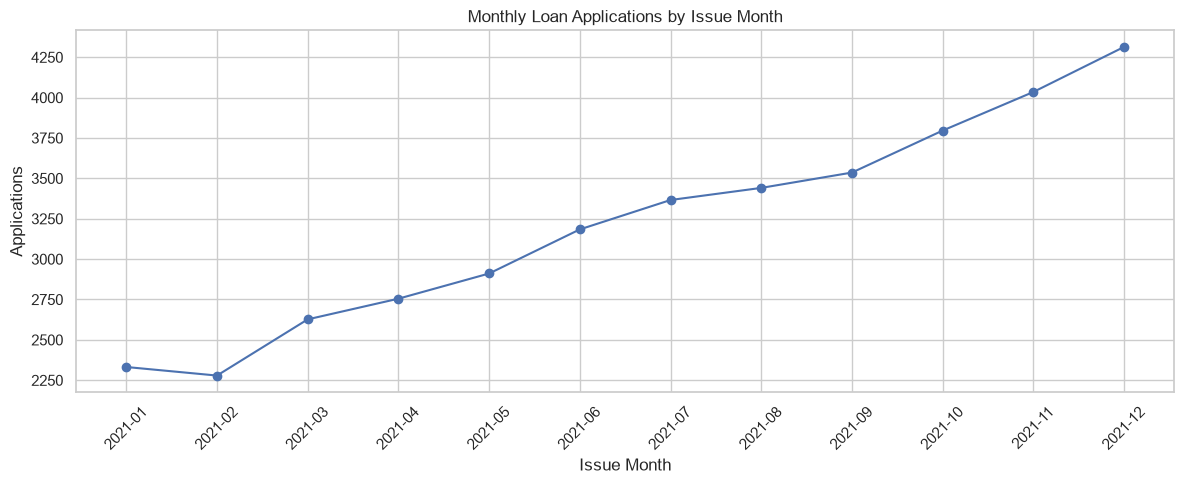

In [32]:
# Visualize the monthly application trend.
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_analysis["issue_year_month"],
    monthly_analysis["applications"],
    marker="o",
)

ax.set_title("Monthly Loan Applications by Issue Month")
ax.set_xlabel("Issue Month")
ax.set_ylabel("Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


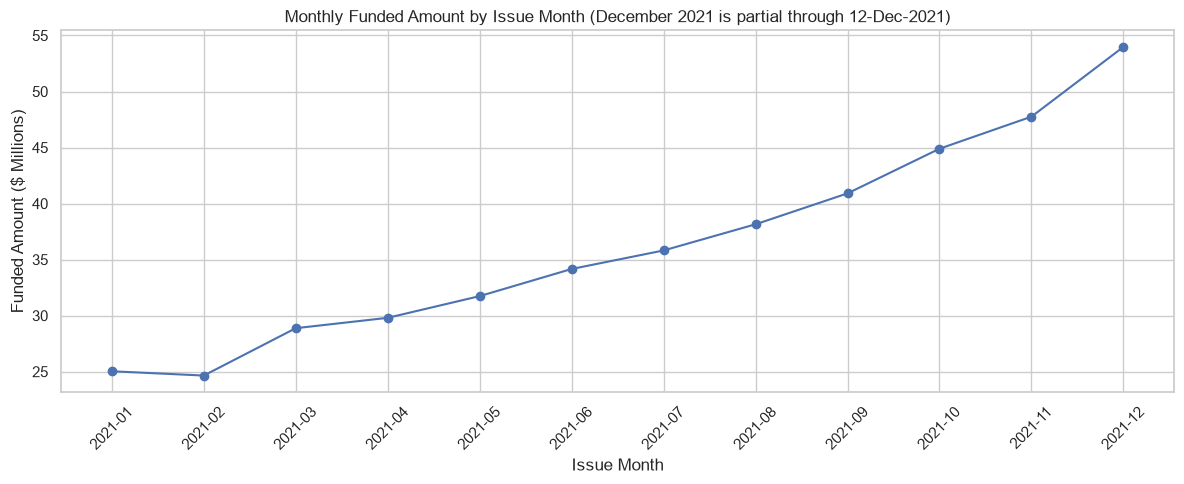

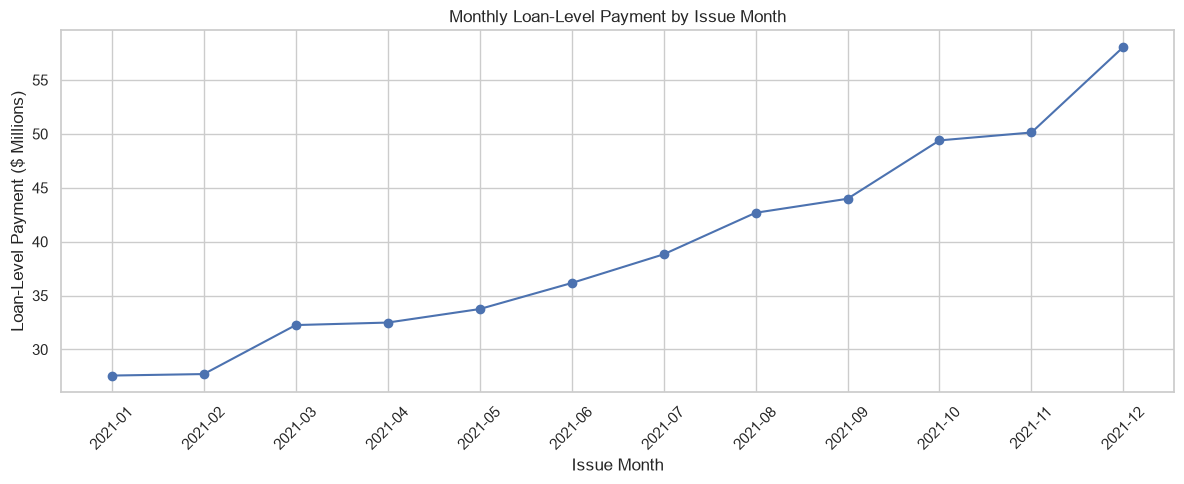

In [33]:
# Visualize the monthly funded amount in $ millions.

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_analysis["issue_year_month"],
    monthly_analysis["funded_amount"] / 1_000_000,
    marker="o",
)
ax.set_title("Monthly Funded Amount by Issue Month (December 2021 is partial through 12-Dec-2021)")
ax.set_xlabel("Issue Month")
ax.set_ylabel("Funded Amount ($ Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize cumulative loan-level payment by issue month.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_analysis["issue_year_month"],
    monthly_analysis["loan_level_payment"] / 1_000_000,
    marker="o",
)
ax.set_title("Monthly Loan-Level Payment by Issue Month")
ax.set_xlabel("Issue Month")
ax.set_ylabel("Loan-Level Payment ($ Millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Business Interpretation
Observed origination activity generally increases through 2021. December has the highest observed application and funded values, but it is a **partial month**, so it should not be presented as a full-month peak.


### 6.5 State Analysis
**Business Questions**

* Which states have the highest loan application volume?
* Which states have the highest funded amount?
* How is lending activity distributed across states?
* How does Bad Loan % vary across states?
* Which meaningful-volume states have Bad Loan % above the overall portfolio rate?

In [34]:
# Table 1: State Portfolio Activity.
state_core = (
    df.groupby("address_state")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .sort_values("applications", ascending=False)
)

state_core.head(10)

,applications,funded_amount,loan_level_payment
address_state,,,
CA,6894,78484125,83901234
NY,3701,42077050,46108181
FL,2773,30046125,31601905
TX,2664,31236650,34392715
NJ,1822,21657475,23425159
IL,1486,17124225,18875941
PA,1482,15826525,17462908
VA,1375,15982650,17711443
GA,1355,15480325,16728040


In [35]:
# Table 2: State Risk and Borrower Profile.

state_risk = (
    df.groupby("address_state")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
          avg_dti=("dti_pct", "mean"),
          avg_interest_rate=("interest_rate_pct", "mean"),
      )
      .reset_index()
)

state_risk["bad_loan_pct"] = (
    state_risk["bad_loans"] / state_risk["applications"] * 100
)

state_risk = state_risk.sort_values("applications", ascending=False)
state_risk.head(10)

,address_state,applications,funded_amount,bad_loans,avg_dti,avg_interest_rate,bad_loan_pct
4,CA,6894,78484125,1057,12.84,12.15,15.33
33,NY,3701,42077050,468,12.21,12.11,12.65
9,FL,2773,30046125,479,13.53,11.98,17.27
42,TX,2664,31236650,301,13.95,12.05,11.30
30,NJ,1822,21657475,273,12.83,12.24,14.98
14,IL,1486,17124225,192,13.31,12.05,12.92
37,PA,1482,15826525,169,13.84,11.69,11.40
44,VA,1375,15982650,170,13.47,12.22,12.36
10,GA,1355,15480325,207,13.99,11.96,15.28
19,MA,1310,15051000,150,12.64,11.87,11.45


In [36]:
# Table 3: High-volume / higher-risk state screening.

volume_threshold = df["id"].nunique() * 0.02
overall_bad_loan_pct = df["loan_category"].eq("Bad Loan").mean() * 100

high_volume_high_risk_states = (
    state_risk[
        (state_risk["applications"] >= volume_threshold) &
        (state_risk["bad_loan_pct"] > overall_bad_loan_pct)
    ]
    .sort_values("bad_loan_pct", ascending=False)
    .reset_index(drop=True)
)

high_volume_high_risk_states[
    [
        "address_state",
        "applications",
        "funded_amount",
        "bad_loans",
        "bad_loan_pct",
        "avg_dti",
        "avg_interest_rate",
    ]
]


,address_state,applications,funded_amount,bad_loans,bad_loan_pct,avg_dti,avg_interest_rate
0,FL,2773,30046125,479,17.27,13.53,11.98
1,CA,6894,78484125,1057,15.33,12.84,12.15
2,GA,1355,15480325,207,15.28,13.99,11.96
3,MD,1027,11911400,155,15.09,12.92,12.49
4,NJ,1822,21657475,273,14.98,12.83,12.24
5,WA,805,8855525,118,14.66,13.05,12.26


### Screening Rule
A state is flagged when it has at least **2% of total portfolio applications** and a Bad Loan rate above the overall portfolio rate. This is a transparent screening rule to reduce small-sample noise; it is not a universal banking threshold.


### Visualisation — State Portfolio and Risk


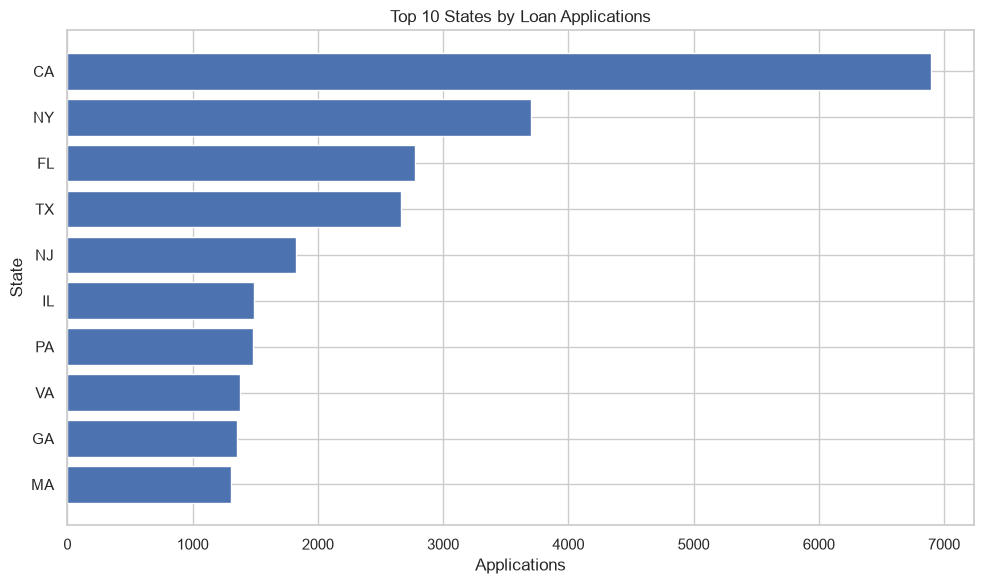

In [37]:
# Top 10 states by application volume.

top_states = state_core.nlargest(10, "applications").sort_values("applications")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_states.index, top_states["applications"])
ax.set_title("Top 10 States by Loan Applications")
ax.set_xlabel("Applications")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

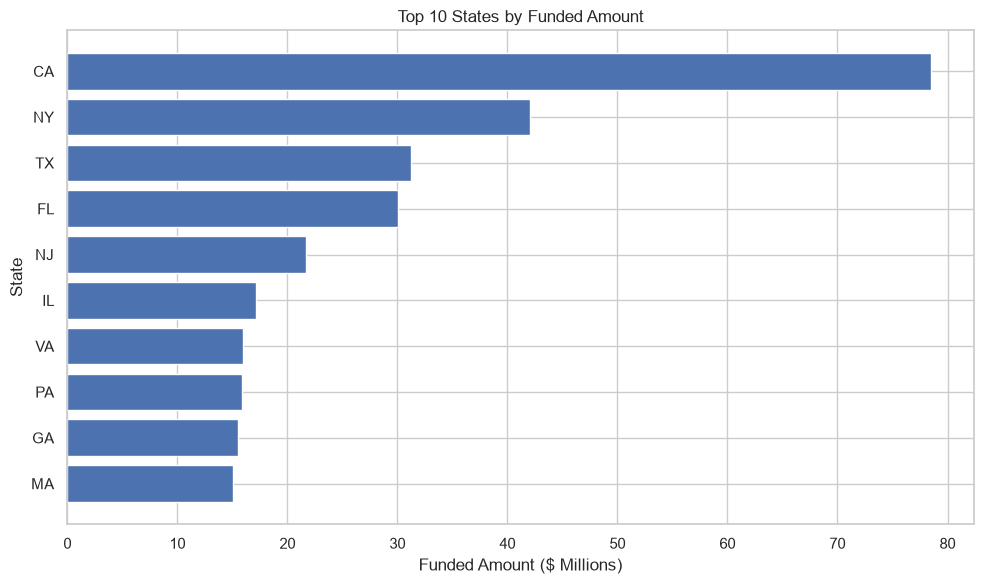

In [38]:
# Top 10 states by funded exposure.
top_funded_states = state_core.nlargest(10, "funded_amount").sort_values("funded_amount")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_funded_states.index, top_funded_states["funded_amount"] / 1_000_000)
ax.set_title("Top 10 States by Funded Amount")
ax.set_xlabel("Funded Amount ($ Millions)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

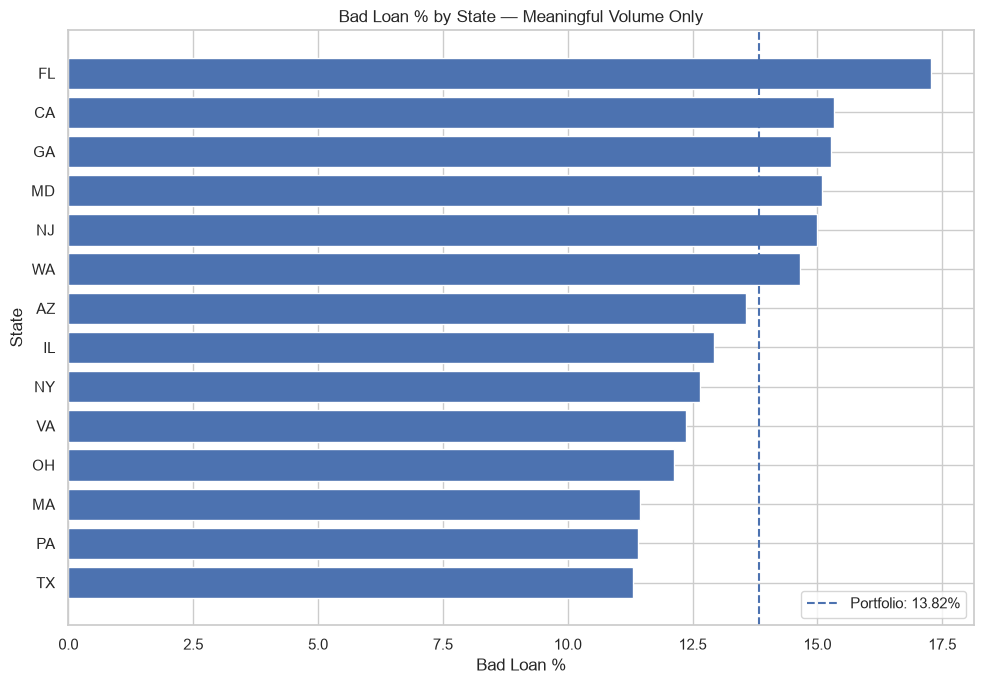

In [39]:
# Bad Loan percentage across states with meaningful volume.

state_risk_plot = state_risk[state_risk["applications"] >= volume_threshold].sort_values("bad_loan_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(state_risk_plot["address_state"], state_risk_plot["bad_loan_pct"])
ax.axvline(overall_bad_loan_pct, linestyle="--", label=f"Portfolio: {overall_bad_loan_pct:.2f}%")
ax.set_title("Bad Loan % by State — Meaningful Volume Only")
ax.set_xlabel("Bad Loan %")
ax.set_ylabel("State")
ax.legend()
plt.tight_layout()
plt.show()


### Business Interpretation
State analysis separates **portfolio concentration** from **observed risk**. California has the highest observed application volume (6,894). Small states can display extreme percentages with very few loans, so volume-qualified comparisons are more meaningful for portfolio monitoring.


### 6.6 Loan Term Analysis
**Business Questions**

* How are loans distributed across available term lengths?
* Which term has the highest application volume?
* Which term has the highest funded amount?
* How does Bad Loan % differ by term?
* How does average interest rate differ by term?

In [40]:
# Table 1: Term portfolio activity.
term_core = (
    df.groupby("term")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .sort_values("applications", ascending=False)
)
term_core


,applications,funded_amount,loan_level_payment
term,,,
36 months,28237,273041225,294709458
60 months,10339,162715850,178361475


In [41]:
# Table 2: Term risk and pricing.
term_risk = (
    df.groupby("term")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
          avg_interest_rate=("interest_rate_pct", "mean"),
          avg_dti=("dti_pct", "mean"),
      )
      .reset_index()
)

term_risk["bad_loan_pct"] = (
    term_risk["bad_loans"] / term_risk["applications"] * 100
)
term_risk


,term,applications,funded_amount,bad_loans,avg_interest_rate,avg_dti,bad_loan_pct
0,36 months,28237,273041225,3023,11.03,12.99,10.71
1,60 months,10339,162715850,2310,14.83,14.26,22.34


In [42]:
# Table 3: Average and median installment by term and original loan status.
term_status_installment = (
    df.groupby(["term", "loan_status"])
      .agg(
          applications=("id", "nunique"),
          avg_installment=("installment", "mean"),
          median_installment=("installment", "median"),
      )
      .reset_index()
)

term_status_installment

,term,loan_status,applications,avg_installment,median_installment
0,36 months,Charged Off,3023,316.79,263.56
1,36 months,Fully Paid,25214,313.95,264.43
2,60 months,Charged Off,2310,372.17,348.44
3,60 months,Current,1098,398.92,369.96
4,60 months,Fully Paid,6931,351.72,318.64


### Visualisation — Term Analysis


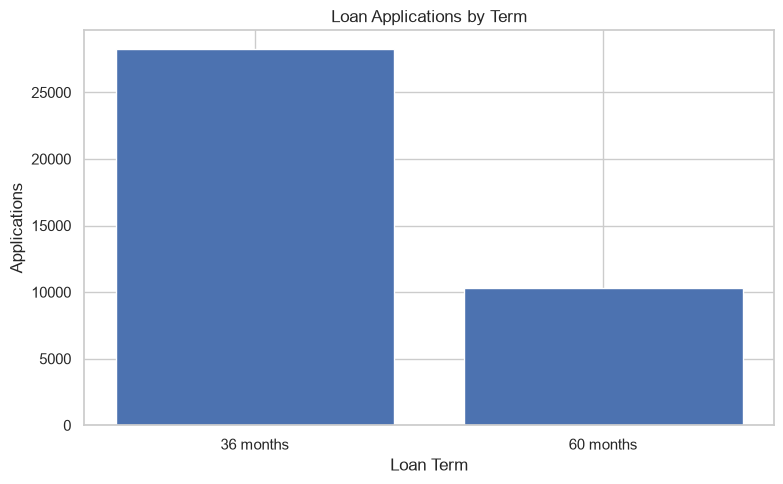

In [43]:
# Applications by loan term.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(term_core.index, term_core["applications"])
ax.set_title("Loan Applications by Term")
ax.set_xlabel("Loan Term")
ax.set_ylabel("Applications")
plt.tight_layout()
plt.show()

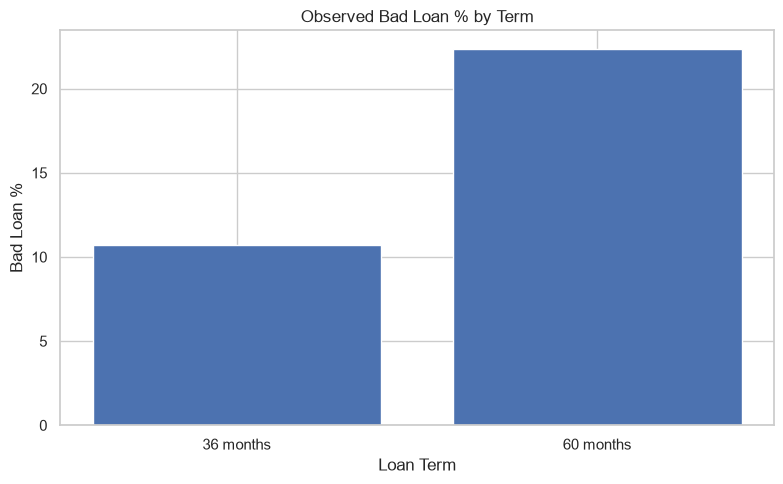

In [44]:
# Bad Loan percentage by term.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(term_risk["term"], term_risk["bad_loan_pct"])
ax.set_title("Observed Bad Loan % by Term")
ax.set_xlabel("Loan Term")
ax.set_ylabel("Bad Loan %")
plt.tight_layout()
plt.show()

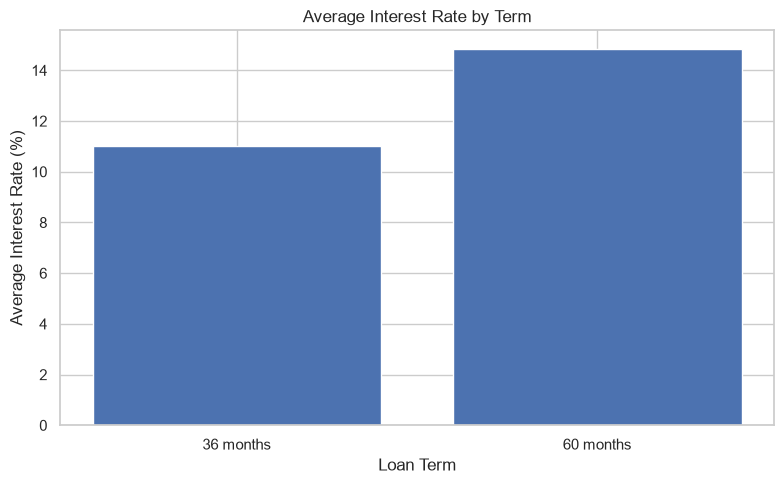

In [45]:
# Average interest rate by term.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(term_risk["term"], term_risk["avg_interest_rate"])
ax.set_title("Average Interest Rate by Term")
ax.set_xlabel("Loan Term")
ax.set_ylabel("Average Interest Rate (%)")
plt.tight_layout()
plt.show()

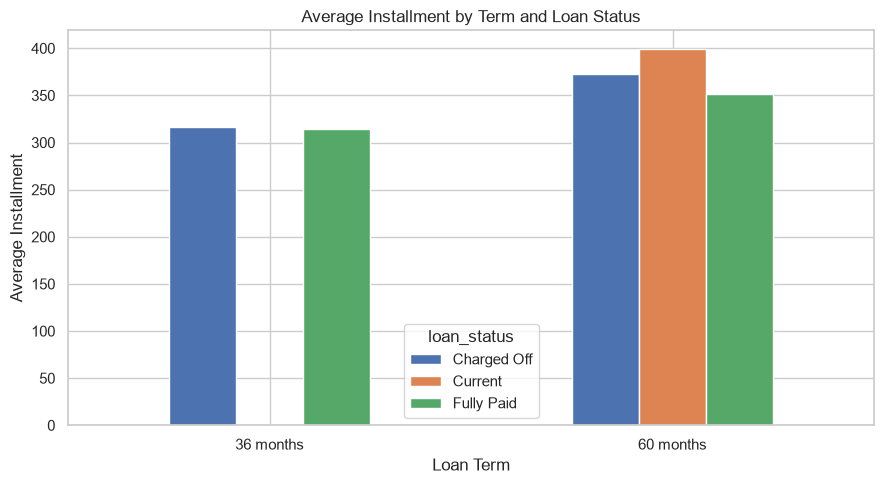

In [46]:
# Average installment by term and loan status.
installment_plot = term_status_installment.pivot(
    index="term", columns="loan_status", values="avg_installment"
)

ax = installment_plot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Average Installment by Term and Loan Status")
ax.set_xlabel("Loan Term")
ax.set_ylabel("Average Installment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Business Interpretation
The 36-month term has the larger application volume, while the 60-month term has a larger average funded amount per loan. Term-level risk, pricing, and installment metrics should be interpreted together rather than using term volume alone.


### 6.7 Employment Length Analysis
**Business Questions**

* How are loan applications distributed across employment lengths?
* Which employment-length groups have the highest funded amount?
* How does lending activity vary across employment lengths?
* How does Bad Loan % differ by employment length?
* How do average DTI and interest rate vary across employment-length groups?

In [47]:
# Table 1: Employment portfolio activity.
employment_core = (
    df.groupby("emp_length", dropna=False)
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .sort_values("applications", ascending=False)
)
employment_core

,applications,funded_amount,loan_level_payment
emp_length,,,
10+ years,8870,116115950,125871616
< 1 year,4575,44210625,47545011
2 years,4382,44967975,49206961
3 years,4088,43937850,47551832
4 years,3428,37600375,40964850
5 years,3273,36973625,40397571
1 year,3229,32883125,35498348
6 years,2228,25612650,27908658
7 years,1772,20811725,22584136


In [48]:
# Table 2: Employment risk and borrower profile.

employment_risk = (
    df.groupby("emp_length", dropna=False)
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
          avg_dti=("dti_pct", "mean"),
          avg_interest_rate=("interest_rate_pct", "mean"),
      )
      .reset_index()
)

employment_risk["bad_loan_pct"] = (
    employment_risk["bad_loans"] / employment_risk["applications"] * 100
)
employment_risk = employment_risk.sort_values("applications", ascending=False)
employment_risk

,emp_length,applications,funded_amount,bad_loans,avg_dti,avg_interest_rate,bad_loan_pct
1,10+ years,8870,116115950,1322,13.72,12.09,14.90
10,< 1 year,4575,44210625,631,12.55,11.92,13.79
2,2 years,4382,44967975,561,13.10,12.07,12.80
3,3 years,4088,43937850,548,13.16,12.02,13.41
4,4 years,3428,37600375,454,13.20,12.17,13.24
5,5 years,3273,36973625,449,13.43,12.03,13.72
0,1 year,3229,32883125,445,13.07,12.05,13.78
6,6 years,2228,25612650,306,13.82,12.07,13.73
7,7 years,1772,20811725,262,13.68,12.18,14.79
8,8 years,1476,17558950,200,13.77,11.91,13.55


### Visualisation — Employment Length


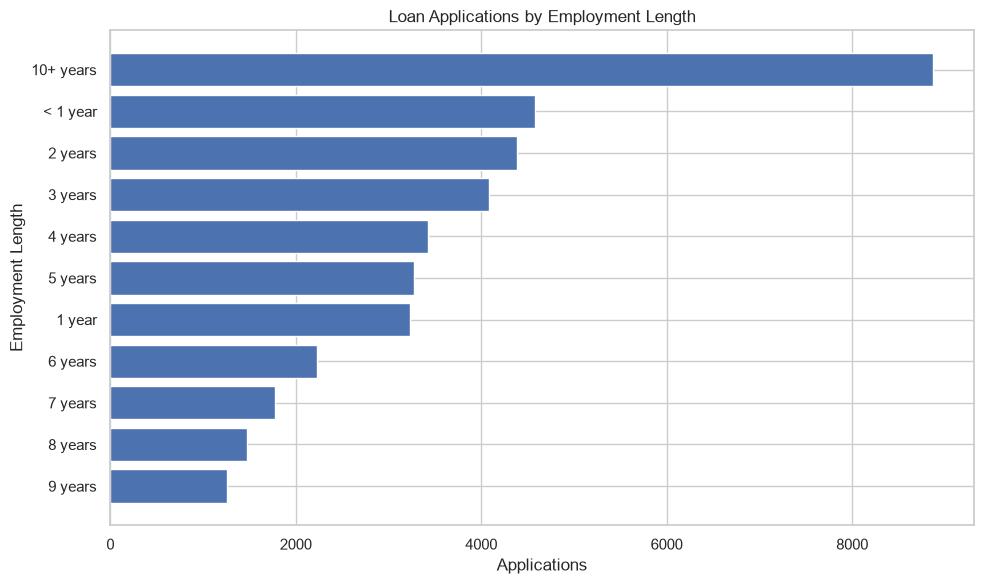

In [49]:
# Application volume by employment length.

employment_plot = employment_core.sort_values("applications")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(employment_plot.index, employment_plot["applications"])
ax.set_title("Loan Applications by Employment Length")
ax.set_xlabel("Applications")
ax.set_ylabel("Employment Length")
plt.tight_layout()
plt.show()

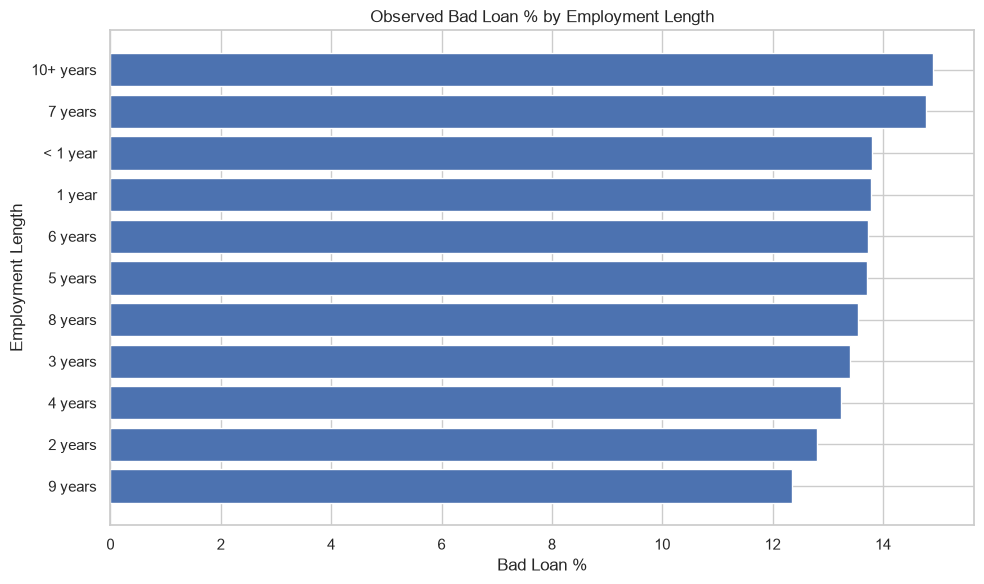

In [50]:
# Bad Loan percentage by employment length.

employment_risk_plot = employment_risk.sort_values("bad_loan_pct")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(employment_risk_plot["emp_length"], employment_risk_plot["bad_loan_pct"])
ax.set_title("Observed Bad Loan % by Employment Length")
ax.set_xlabel("Bad Loan %")
ax.set_ylabel("Employment Length")
plt.tight_layout()
plt.show()

### Business Interpretation
The **10+ years** group has the largest application volume and funded exposure. Employment length provides a useful segmentation view, but observed risk differences should be interpreted alongside the size of each employment group.



### 6.8 Loan Purpose Analysis
**Business Questions**

* Which loan purposes have the highest application volume?
* Which purposes have the highest funded amount?
* How is lending activity distributed across loan purposes?
* How does Bad Loan % differ by purpose?
* Which meaningful-volume purposes have Bad Loan % above the overall portfolio rate?

In [51]:
# Table 1: Purpose portfolio activity.

purpose_core = (
    df.groupby("purpose")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .sort_values("applications", ascending=False)
)
purpose_core


,applications,funded_amount,loan_level_payment
purpose,,,
Debt consolidation,18214,232459675,253801871
credit card,4998,58885175,65214084
other,3824,31155750,33289676
home improvement,2876,33350775,36380930
major purchase,2110,17251600,18676927
small business,1776,24123100,23814817
car,1497,10223575,11324914
wedding,928,9225800,10266856
medical,667,5533225,5851372


In [52]:
# Table 2: Purpose risk and borrower profile.

purpose_risk = (
    df.groupby("purpose")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
          avg_dti=("dti_pct", "mean"),
          avg_interest_rate=("interest_rate_pct", "mean"),
      )
      .reset_index()
)

purpose_risk["bad_loan_pct"] = (
    purpose_risk["bad_loans"] / purpose_risk["applications"] * 100
)
purpose_risk = purpose_risk.sort_values("applications", ascending=False)
purpose_risk


,purpose,applications,funded_amount,bad_loans,avg_dti,avg_interest_rate,bad_loan_pct
0,Debt consolidation,18214,232459675,2651,14.48,12.50,14.55
2,credit card,4998,58885175,508,14.63,11.73,10.16
9,other,3824,31155750,587,12.29,11.86,15.35
4,home improvement,2876,33350775,327,11.11,11.40,11.37
6,major purchase,2110,17251600,206,10.83,10.87,9.76
11,small business,1776,24123100,455,11.14,13.03,25.62
1,car,1497,10223575,155,11.18,10.59,10.35
13,wedding,928,9225800,86,12.26,11.89,9.27
7,medical,667,5533225,100,12.22,11.57,14.99
8,moving,559,3748125,84,11.68,11.59,15.03


In [53]:
# Table 3: High-volume / higher-risk purpose screening.

purpose_volume_threshold = df["id"].nunique() * 0.02

overall_bad_loan_pct = df["loan_category"].eq("Bad Loan").mean() * 100

high_volume_high_risk_purposes = (
    purpose_risk[
        (purpose_risk["applications"] >= purpose_volume_threshold) &
        (purpose_risk["bad_loan_pct"] > overall_bad_loan_pct)
    ]
    .sort_values("bad_loan_pct", ascending=False)
    .reset_index(drop=True)
)

high_volume_high_risk_purposes[
    [
        "purpose",
        "applications",
        "funded_amount",
        "bad_loans",
        "bad_loan_pct",
        "avg_dti",
        "avg_interest_rate",
    ]
]


,purpose,applications,funded_amount,bad_loans,bad_loan_pct,avg_dti,avg_interest_rate
0,small business,1776,24123100,455,25.62,11.14,13.03
1,other,3824,31155750,587,15.35,12.29,11.86
2,Debt consolidation,18214,232459675,2651,14.55,14.48,12.50


### Visualisation — Loan Purpose


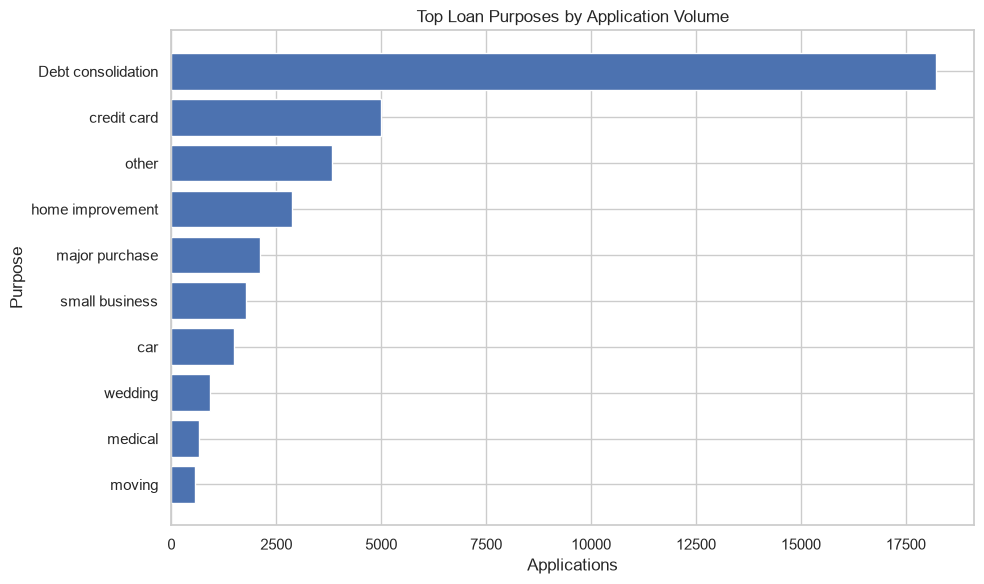

In [54]:
# Top purposes by application volume.

top_purposes = purpose_core.nlargest(10, "applications").sort_values("applications")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_purposes.index, top_purposes["applications"])
ax.set_title("Top Loan Purposes by Application Volume")
ax.set_xlabel("Applications")
ax.set_ylabel("Purpose")
plt.tight_layout()
plt.show()


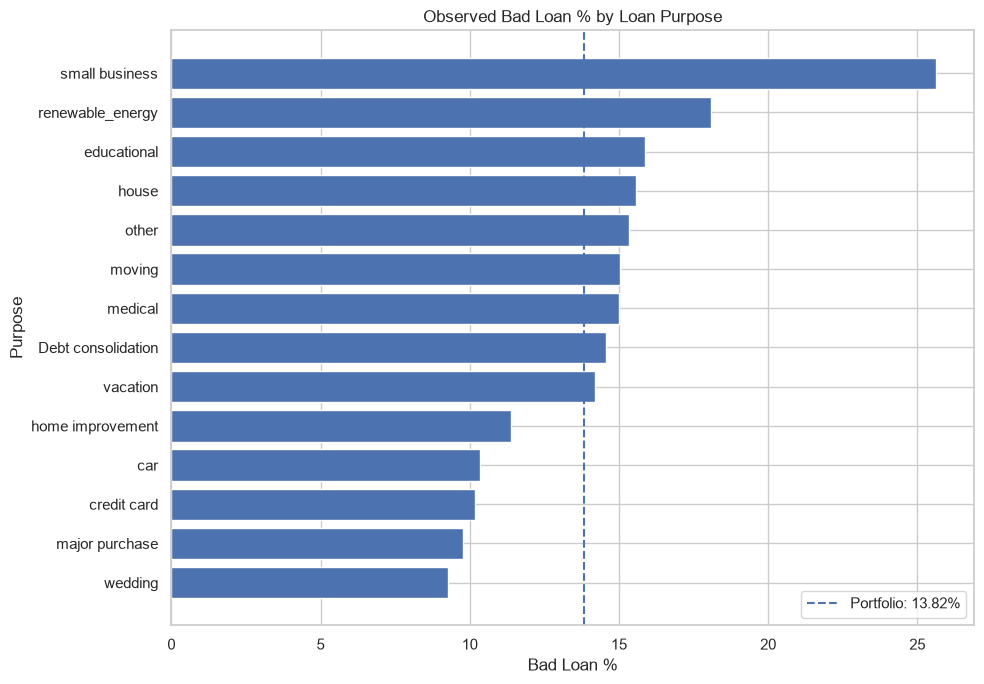

In [55]:
# Bad Loan percentage by purpose.

purpose_risk_plot = purpose_risk.sort_values("bad_loan_pct")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(purpose_risk_plot["purpose"], purpose_risk_plot["bad_loan_pct"])
ax.axvline(overall_bad_loan_pct, linestyle="--", label=f"Portfolio: {overall_bad_loan_pct:.2f}%")
ax.set_title("Observed Bad Loan % by Loan Purpose")
ax.set_xlabel("Bad Loan %")
ax.set_ylabel("Purpose")
ax.legend()
plt.tight_layout()
plt.show()


### Business Interpretation
**Debt consolidation** is the largest observed purpose by application volume and funded exposure. Purpose-level risk should be evaluated with volume and exposure together so that small categories are not overemphasized because of volatile percentages.


### 6.9 Home Ownership Analysis
**Business Questions**

* How are loan applications distributed across home-ownership categories?
* Which home-ownership categories have the highest funded amount?
* How does lending activity vary across home-ownership categories?
* How does Bad Loan % differ by home ownership?
* How does average DTI vary across home-ownership categories?

In [56]:
# Table 1: Home-ownership portfolio activity.
home_core = (
    df.groupby("home_ownership", dropna=False)
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          loan_level_payment=("total_payment", "sum"),
      )
      .sort_values("applications", ascending=False)
)
home_core

,applications,funded_amount,loan_level_payment
home_ownership,,,
RENT,18439,185768475,201823056
MORTGAGE,17198,219329150,238474438
OWN,2838,29597675,31729129
OTHER,98,1044975,1025257
NONE,3,16800,19053


In [57]:
# Table 2: Home-ownership risk and borrower profile.

home_risk = (
    df.groupby("home_ownership", dropna=False)
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
          avg_dti=("dti_pct", "mean"),
          avg_interest_rate=("interest_rate_pct", "mean"),
      )
      .reset_index()
)

home_risk["bad_loan_pct"] = (
    home_risk["bad_loans"] / home_risk["applications"] * 100
)
home_risk = home_risk.sort_values("applications", ascending=False)
home_risk


,home_ownership,applications,funded_amount,bad_loans,avg_dti,avg_interest_rate,bad_loan_pct
4,RENT,18439,185768475,2687,13.50,12.30,14.57
0,MORTGAGE,17198,219329150,2231,13.17,11.80,12.97
3,OWN,2838,29597675,397,13.24,11.89,13.99
2,OTHER,98,1044975,18,11.25,12.04,18.37
1,NONE,3,16800,0,11.75,8.70,0.00


### Visualisation — Home Ownership


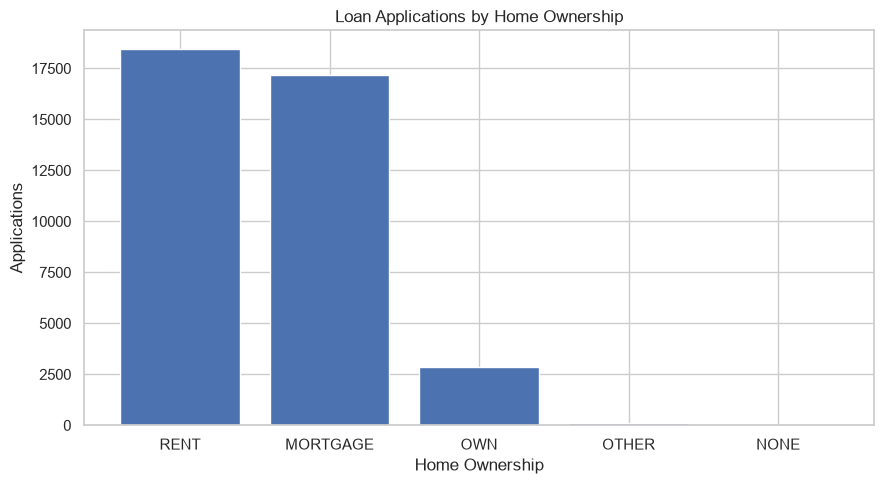

In [58]:
# Application volume by home ownership.

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(home_core.index, home_core["applications"])
ax.set_title("Loan Applications by Home Ownership")
ax.set_xlabel("Home Ownership")
ax.set_ylabel("Applications")
plt.tight_layout()
plt.show()


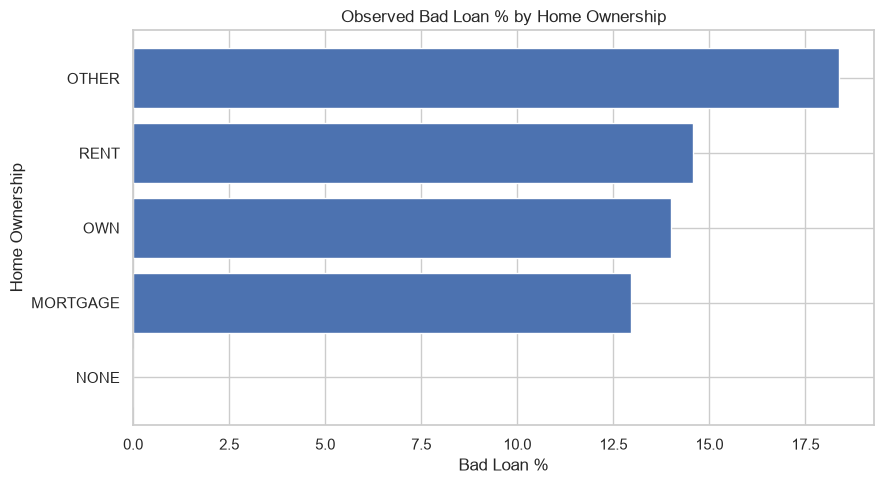

In [59]:
# Bad Loan percentage by home ownership.

home_risk_plot = home_risk.sort_values("bad_loan_pct")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(home_risk_plot["home_ownership"], home_risk_plot["bad_loan_pct"])
ax.set_title("Observed Bad Loan % by Home Ownership")
ax.set_xlabel("Bad Loan %")
ax.set_ylabel("Home Ownership")
plt.tight_layout()
plt.show()


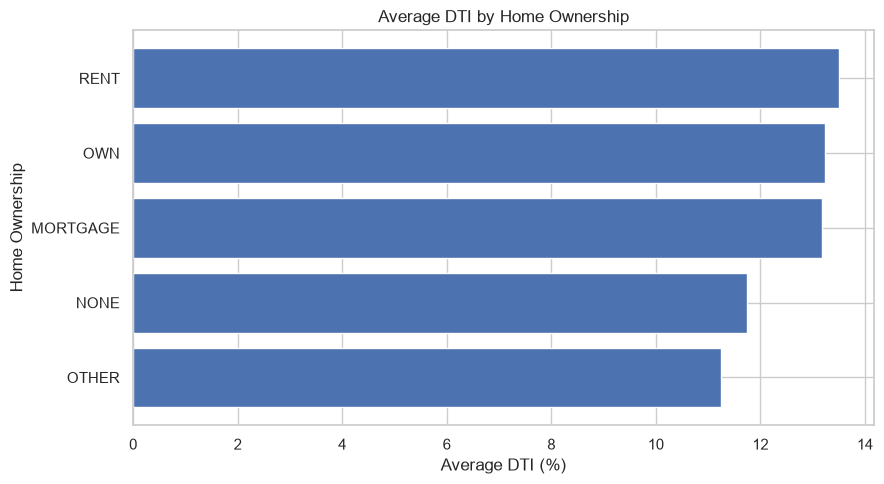

In [60]:
# Average DTI by home ownership.
home_dti_plot = home_risk.sort_values("avg_dti")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(home_dti_plot["home_ownership"], home_dti_plot["avg_dti"])
ax.set_title("Average DTI by Home Ownership")
ax.set_xlabel("Average DTI (%)")
ax.set_ylabel("Home Ownership")
plt.tight_layout()
plt.show()


### Business Interpretation
**RENT** is the largest application segment, while **MORTGAGE** has the largest funded exposure. Among the major categories, observed Bad Loan rates are close but not identical, and average DTI is also relatively similar. Very small categories such as `NONE` should be interpreted cautiously.


# 7. Additional Risk Insights

### 7.1 Grade vs Bad Loan %
**Business Questions**

* How does loan application volume vary across grades?
* How does Bad Loan % vary across grades?
* Which grades show higher or lower observed Bad Loan rates?

In [61]:
# Compare grade-level volume, exposure, and observed Bad Loan performance.
grade_risk = (
    df.groupby("grade")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          avg_interest_rate=("interest_rate_pct", "mean"),
          avg_dti=("dti_pct", "mean"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
      )
      .sort_index()
)

grade_risk["bad_loan_pct"] = (
    grade_risk["bad_loans"] / grade_risk["applications"] * 100
)
grade_risk

,applications,funded_amount,avg_interest_rate,avg_dti,bad_loans,bad_loan_pct
grade,,,,,,
A,9689,84252225,7.35,12.04,552,5.70
B,11674,130703975,11.03,13.43,1343,11.50
C,7904,87456450,13.55,13.92,1266,16.02
D,5182,63920800,15.71,13.98,1072,20.69
E,2786,44165100,17.71,14.10,691,24.80
F,1028,18910450,19.74,14.17,311,30.25
G,313,6348075,21.40,14.06,98,31.31


### Visualisation


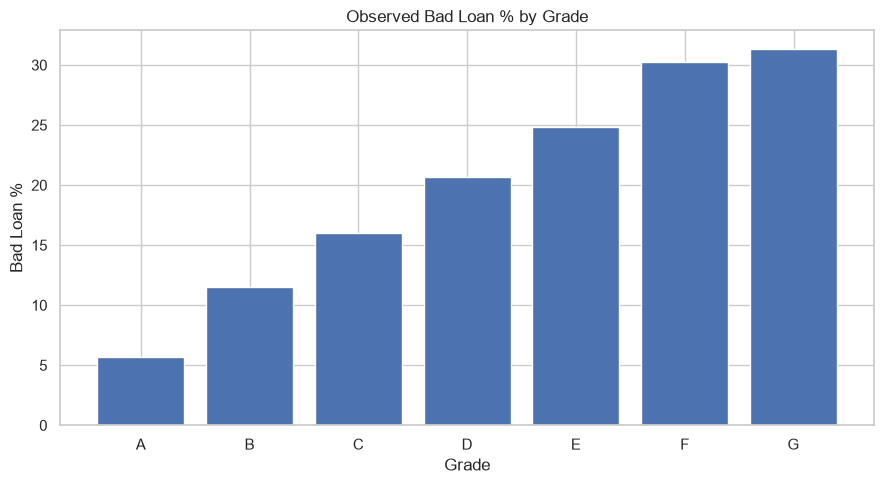

In [62]:
# Visualize observed Bad Loan rates by grade.
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(grade_risk.index, grade_risk["bad_loan_pct"])
ax.set_title("Observed Bad Loan % by Grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Bad Loan %")
plt.tight_layout()
plt.show()


### Business Interpretation
Grades provide a compact risk segmentation view. In this dataset, observed Bad Loan rates differ across grades; the result should be described as an observed segment pattern rather than a causal effect of the grade itself.


### 7.2 Grade vs Interest Rate
**Business Questions**

* How does average interest rate vary across grades?
* How does loan volume differ across grades alongside pricing?
* Is there an observable relationship between grade category and interest-rate level?

In [63]:
# Calculate average pricing by grade.
grade_pricing = (
    df.groupby("grade")["interest_rate_pct"]
      .mean()
      .sort_index()
      .to_frame("avg_interest_rate_pct")
)
grade_pricing

,avg_interest_rate_pct
grade,
A,7.35
B,11.03
C,13.55
D,15.71
E,17.71
F,19.74
G,21.40


### Visualisation


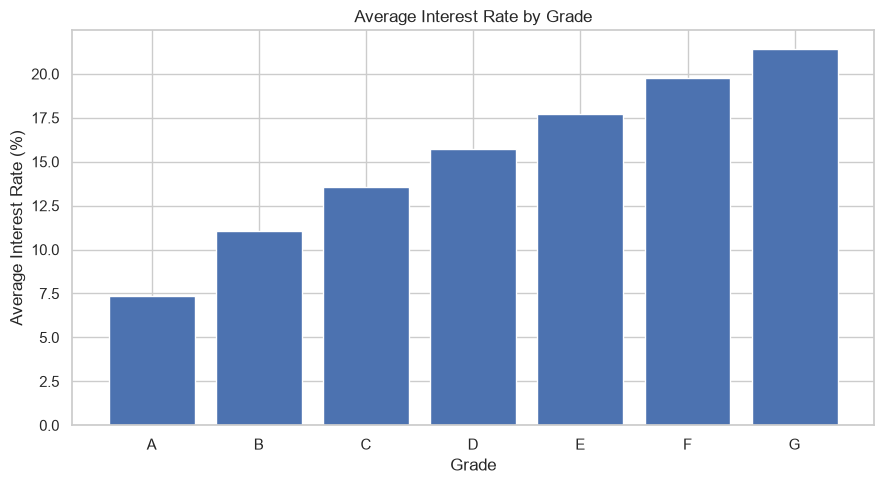

In [64]:
# Visualize average interest rate by grade.
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(grade_pricing.index, grade_pricing["avg_interest_rate_pct"])
ax.set_title("Average Interest Rate by Grade")
ax.set_xlabel("Grade")
ax.set_ylabel("Average Interest Rate (%)")
plt.tight_layout()
plt.show()

### Business Interpretation
Interest rates vary across the grade spectrum, providing a useful view of observed pricing differences across risk classifications.


### 7.3 Sub-Grade Risk Drill-Down
**Business Questions**

* How does Bad Loan % vary within each grade at the sub-grade level?
* Which sub-grades have notable observed Bad Loan rates?
* How does application volume vary across sub-grades?

In [65]:
# Calculate observed Bad Loan rates and pricing for each Sub Grade.
subgrade_risk = (
    df.groupby("sub_grade")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          avg_interest_rate=("interest_rate_pct", "mean"),
          avg_dti=("dti_pct", "mean"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
      )
)

subgrade_risk["bad_loan_pct"] = (
    subgrade_risk["bad_loans"] / subgrade_risk["applications"] * 100
)

subgrade_risk.sort_values("applications", ascending=False).head(10)


,applications,funded_amount,avg_interest_rate,avg_dti,bad_loans,bad_loan_pct
sub_grade,,,,,,
B3,2834,33061350,11.00,13.46,325,11.47
A4,2803,26426425,7.66,12.38,168,5.99
A5,2654,25784525,8.27,12.54,204,7.69
B5,2644,30940900,11.79,13.84,344,13.01
B4,2455,28296300,11.41,13.68,312,12.71
C1,2089,23497800,12.85,13.82,317,15.17
B2,1990,21144550,10.49,13.11,210,10.55
C2,1972,22649200,13.35,13.85,301,15.26
B1,1751,17260875,10.01,12.78,152,8.68


### Visualisation


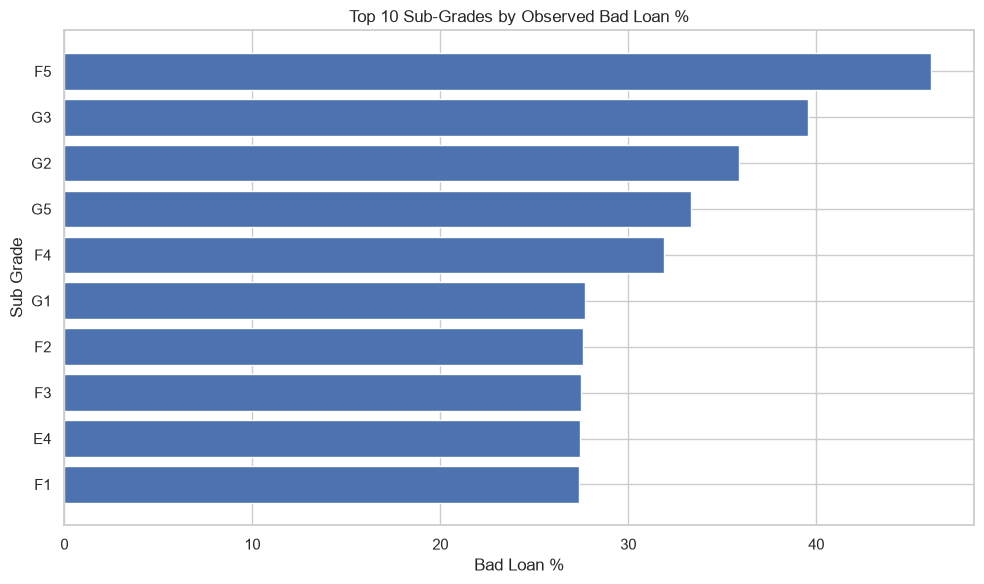

In [66]:
# Plot the ten sub-grades with the highest observed Bad Loan rates.
top_subgrades = subgrade_risk.sort_values("bad_loan_pct", ascending=False).head(10).sort_values("bad_loan_pct")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_subgrades.index, top_subgrades["bad_loan_pct"])
ax.set_title("Top 10 Sub-Grades by Observed Bad Loan %")
ax.set_xlabel("Bad Loan %")
ax.set_ylabel("Sub Grade")
plt.tight_layout()
plt.show()


### Business Interpretation
Sub Grade provides finer segmentation within Grade. Because some Sub Grades have lower volume than the broad Grade categories, both the rate and application count should be considered together.


### 7.4 Verification Status vs Bad Loan %
**Business Questions**

* How is loan activity distributed across verification-status categories?
* How does Bad Loan % vary by verification status?
* Do meaningful differences in observed loan performance appear across verification categories?

In [67]:
# Compare verification categories with observed Bad Loan performance.
verification_risk = (
    df.groupby("verification_status")
      .agg(
          applications=("id", "nunique"),
          funded_amount=("loan_amount", "sum"),
          avg_interest_rate=("interest_rate_pct", "mean"),
          avg_dti=("dti_pct", "mean"),
          bad_loans=("loan_category", lambda x: (x == "Bad Loan").sum()),
      )
      .reset_index()
)

verification_risk["bad_loan_pct"] = (
    verification_risk["bad_loans"] / verification_risk["applications"] * 100
)
verification_risk


,verification_status,applications,funded_amount,avg_interest_rate,avg_dti,bad_loans,bad_loan_pct
0,Not Verified,16464,139697450,11.23,13.04,2015,12.24
1,Source Verified,9777,99097575,12.12,12.65,1382,14.14
2,Verified,12335,196962050,13.09,14.24,1936,15.70


### Visualisation


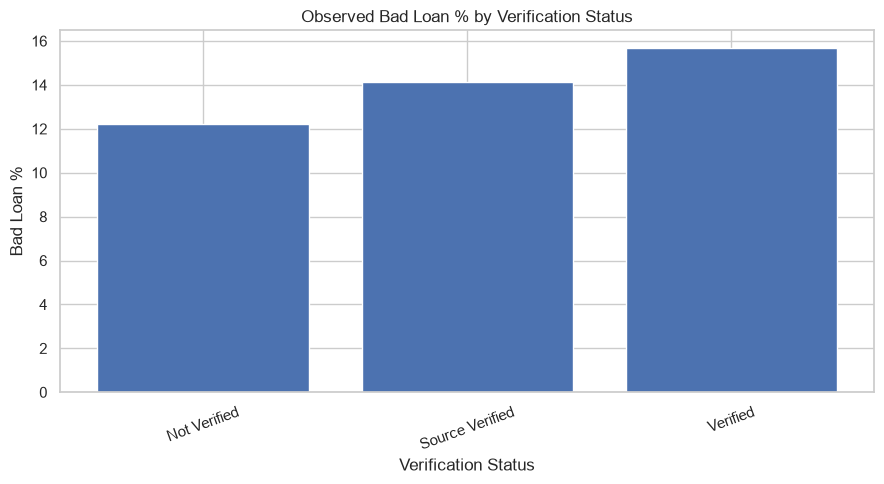

In [68]:
# Visualize observed Bad Loan rates by verification status.
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(verification_risk["verification_status"], verification_risk["bad_loan_pct"])
ax.set_title("Observed Bad Loan % by Verification Status")
ax.set_xlabel("Verification Status")
ax.set_ylabel("Bad Loan %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Business Interpretation
Verification categories show different observed Bad Loan rates in the dataset. These differences describe portfolio composition; they should not be interpreted as proof that verification status itself causes different outcomes.


### 7.5 DTI vs Loan Status
**Business Questions**

* How does average DTI differ across loan statuses?
* How is the DTI distribution different across loan statuses?
* Are there observable differences in borrower debt-burden levels across loan outcomes?

In [69]:
# Summarize DTI distribution by original loan status.

dti_by_status = (
    df.groupby("loan_status")["dti_pct"]
      .agg(
          applications="count",
          mean="mean",
          median="median",
          std="std",
      )
      .sort_values("mean")
)

dti_by_status


,applications,mean,median,std
loan_status,,,,
Fully Paid,32145,13.17,13.21,6.67
Charged Off,5333,14.00,14.32,6.56
Current,1098,14.72,15.01,6.74


### Visualisation


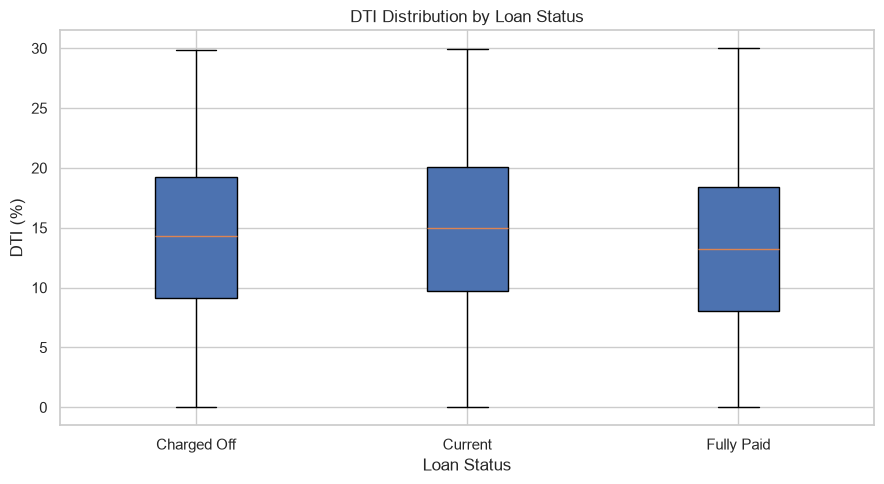

In [70]:
# Compare the full DTI distributions across loan statuses using Matplotlib.
status_order = sorted(df["loan_status"].dropna().unique())
box_data = [df.loc[df["loan_status"] == status, "dti_pct"] for status in status_order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(box_data, tick_labels=status_order, patch_artist=True)
ax.set_title("DTI Distribution by Loan Status")
ax.set_xlabel("Loan Status")
ax.set_ylabel("DTI (%)")
plt.tight_layout()
plt.show()


### Business Interpretation
Average DTI alone can hide distributional differences. The boxplot shows the spread, median, and unusual observations for each loan-status group, providing more context than the portfolio-level average alone.


### 7.6 Term × Loan Status — Average Installment
**Business Questions**

* How does average installment vary by loan term?
* How does average installment vary across loan statuses?
* How does average installment change when term and loan status are considered together?
* How does median installment compare with average installment across these groups?

In [71]:
# Compare average and median installment across term and loan status.

term_status_installment = (
    df.groupby(["term", "loan_status"])
      .agg(
          applications=("id", "nunique"),
          avg_installment=("installment", "mean"),
          median_installment=("installment", "median"),
      )
      .reset_index()
)

term_status_installment

,term,loan_status,applications,avg_installment,median_installment
0,36 months,Charged Off,3023,316.79,263.56
1,36 months,Fully Paid,25214,313.95,264.43
2,60 months,Charged Off,2310,372.17,348.44
3,60 months,Current,1098,398.92,369.96
4,60 months,Fully Paid,6931,351.72,318.64


### Visualisation


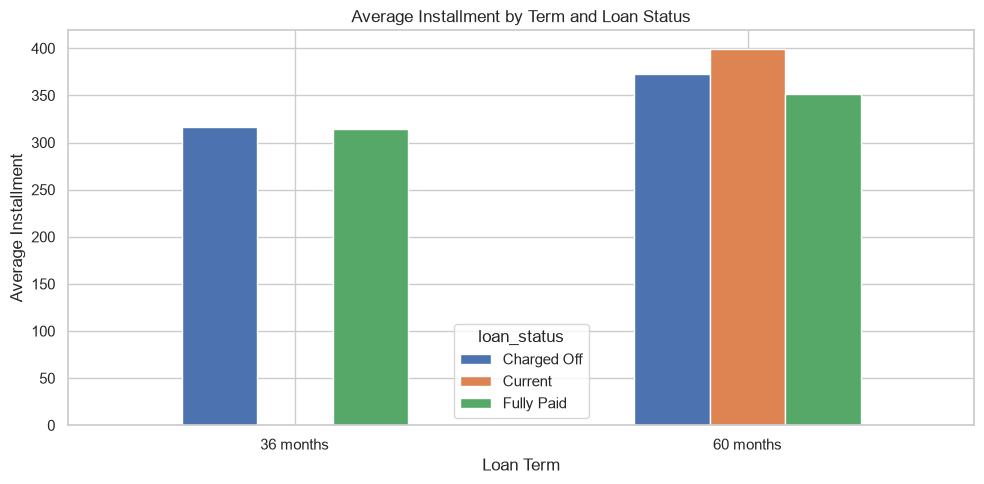

In [72]:
# Plot average installment by term and loan status.

installment_plot = term_status_installment.pivot(
    index="term", columns="loan_status", values="avg_installment"
)

ax = installment_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Average Installment by Term and Loan Status")
ax.set_xlabel("Loan Term")
ax.set_ylabel("Average Installment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Business Interpretation
Installment levels differ across repayment terms and loan statuses. Mean and median values are reported together because installment amounts can be unevenly distributed.


# 8. Supporting EDA

These analyses provide additional context without becoming the main business story.


## 8.1 Annual Income vs Loan Amount

### Purpose
Understand whether borrower income and loan size move together.


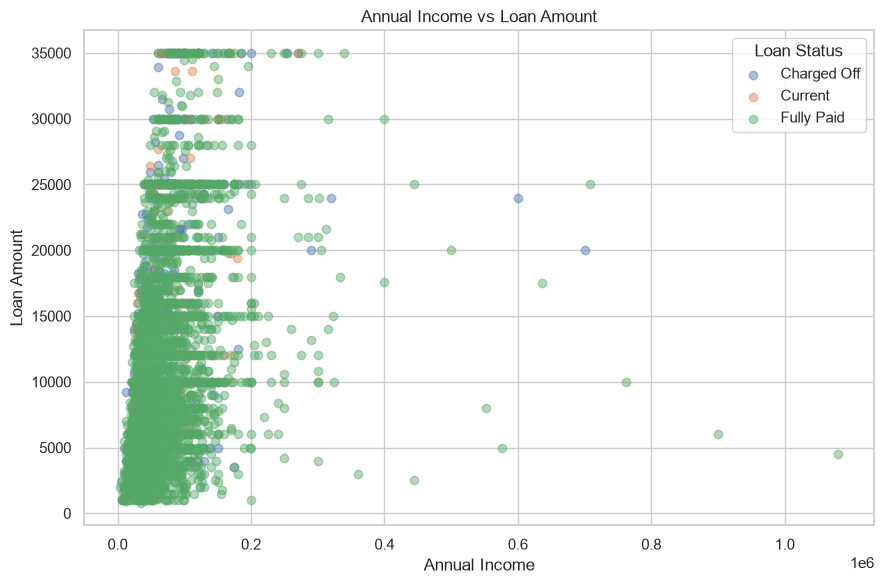

In [73]:
# Sample the dataset only for plotting so the scatter plot remains readable.
sample_size = min(5000, len(df))
plot_sample = df.sample(sample_size, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

for status in sorted(plot_sample["loan_status"].dropna().unique()):
    subset = plot_sample[plot_sample["loan_status"] == status]
    ax.scatter(
        subset["annual_income"],
        subset["loan_amount"],
        label=status,
        alpha=0.45,
    )

ax.set_title("Annual Income vs Loan Amount")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Loan Amount")
ax.legend(title="Loan Status")
plt.tight_layout()
plt.show()


## 8.2 Loan Amount Distribution

### Purpose
Understand the typical loan size, spread, and distribution shape.


In [74]:
# Review distribution statistics including useful percentiles.
loan_amount_stats = (
    df["loan_amount"]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .to_frame("loan_amount")
)

loan_amount_stats

,loan_amount
count,"38,576.00"
mean,"11,296.07"
std,"7,460.75"
min,500.00
1%,"1,200.00"
25%,"5,500.00"
50%,"10,000.00"
75%,"15,000.00"
99%,"35,000.00"
max,"35,000.00"


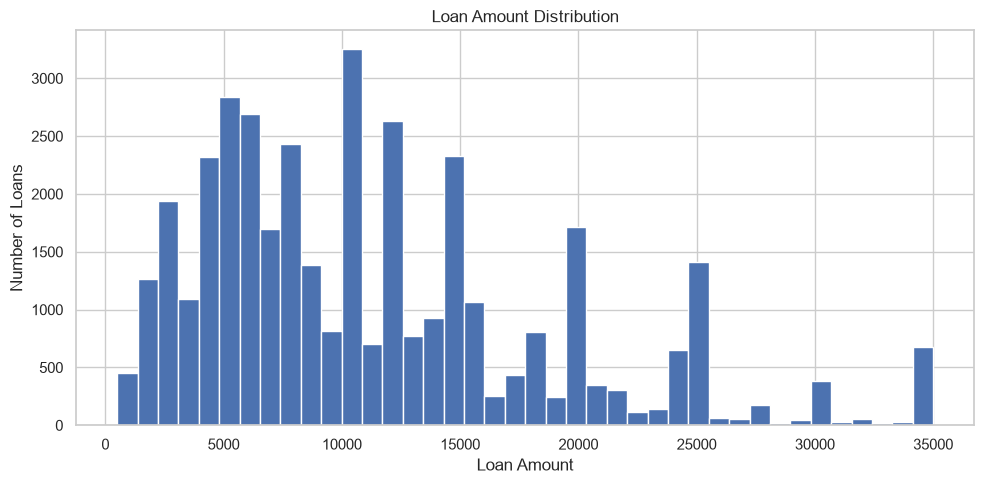

In [75]:
# Visualize loan amount distribution.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["loan_amount"], bins=40)
ax.set_title("Loan Amount Distribution")
ax.set_xlabel("Loan Amount")
ax.set_ylabel("Number of Loans")
plt.tight_layout()
plt.show()

# 9. KPI Summary

## Portfolio KPIs

| KPI                     |        Value |
| ------------------------ | -----------: |
| Total Loan Applications |   **38,576** |
| Total Funded Amount     | **\$435.76M** |
| Total Amount Received*  | **\$473.07M** |
| Average Interest Rate   |   **12.05%** |
| Average DTI             |   **13.33%** |

## MTD KPIs

| KPI                        |           Value |
| --------------------------- | --------------: |
| Reporting Date             | **12-Dec-2021** |
| MTD Loan Applications      |       **4,314** |
| MTD Funded Amount          |     **\$53.98M** |
| MTD Total Amount Received* |     **\$58.07M** |

## Good vs Bad Loan KPIs

| KPI                              |        Value |
| ---------------------------------- | -----------: |
| Good Loan Applications           |   **33,243** |
| Good Loan %                      |   **86.18%** |
| Good Loan Funded Amount          | **\$370.22M** |
| Good Loan Total Amount Received* | **\$435.79M** |
| Bad Loan Applications            |    **5,333** |
| Bad Loan %                       |   **13.82%** |
| Bad Loan Funded Amount           |  **\$65.53M** |
| Bad Loan Total Amount Received*  |  **\$37.28M** |

> **Note:** `total_payment` is a cumulative loan-level payment field, not a transaction-level cash-collection measure. Therefore, "Total Amount Received" and its MTD/segment variations should be interpreted as loan-level payment amounts recorded in the dataset.

# 10. Key Insights

### Portfolio Overview

* The dataset contains **38,576 loan applications** representing approximately **\$435.76M in funded principal**.
* The portfolio has an average interest rate of **12.05%** and an average DTI of **13.33%**.
* The recorded cumulative loan-level payment amount is approximately **\$473.07M**.

### Loan Performance

* Under the project's analytical classification, **86.18% of loans are Good Loans** and **13.82% are Bad Loans**.
* Good Loans account for approximately **\$370.22M** in funded principal, while Bad Loans account for approximately **\$65.53M**.
* Bad Loans therefore represent a somewhat larger share of funded principal than of total loan count.

### Origination Trend

* Loan application activity generally increased across the observed 2021 period.
* Applications increased from **2,332 in January** to **4,314 in the observed December period**.
* Funded amount increased from approximately **\$25.03M in January** to **\$53.98M in the observed December period**.
* December 2021 is a **partial month through 12-Dec-2021**, so it should not be treated as a complete-month peak.

### Geographic Concentration

* **California** has the highest observed loan application volume with **6,894 applications**.
* State-level analysis shows that portfolio concentration and Bad Loan rates should be considered together rather than evaluating risk using percentages alone.

### Loan Characteristics

* **36-month loans** account for the majority of applications, with **28,237 loans**, compared with **10,339 60-month loans**.
* **Debt consolidation** is the largest loan purpose, with **18,214 applications** and approximately **\$232.46M** in funded amount.
* **10+ years of employment** represents the largest employment-length segment with **8,870 applications**.
* **RENT** is the largest home-ownership category by application volume, while **MORTGAGE** has the largest funded exposure.

### Risk Interpretation

* Segment-level Bad Loan rates vary across states, terms, purposes, employment groups, and home-ownership categories.
* Small-volume segments should be interpreted cautiously because percentages based on very few observations can be unstable.
* The analysis identifies **where portfolio activity and observed risk differ**, but does not establish that a specific borrower characteristic causes loan performance outcomes.

# 11. Business Interpretation

The analysis connects portfolio scale, lending activity, borrower characteristics, and observed loan performance to provide a consolidated view of the loan portfolio.

### Portfolio Scale & Financial Position

* Interpret the overall number of loan applications and funded exposure.
* Explain the portfolio's average interest rate and borrower DTI in business terms.
* Relate funded amount to the recorded loan-level payment amount, while recognizing the limitation of the `total_payment` field.

### Loan Performance

* Explain the Good Loan and Bad Loan composition.
* Discuss the difference between loan-count mix and funded-dollar exposure.
* Identify where observed Bad Loan concentration appears in the portfolio.

### Origination Trends

* Explain the monthly movement in loan applications and funded amount.
* Identify important changes in origination activity over the observed period.
* Treat December 2021 as a partial period through 12-Dec-2021.

### Portfolio Concentration

* Explain which states, loan terms, employment groups, purposes, and home-ownership categories contain the largest share of lending activity.
* Distinguish high-volume segments from high-risk segments.

### Risk & Pricing Insights

* Interpret differences in Bad Loan % across grades, sub-grades, states, terms, purposes, employment groups, home ownership, and verification status.
* Explain how interest-rate levels vary across grade and term categories.
* Interpret DTI and installment differences across loan-status groups.

# 12. Business Recommendations

The following recommendations are based on the observed portfolio patterns and are intended as **monitoring, review, and investigation actions**. They do not imply that any individual segment characteristic causes loan performance outcomes.

1. **Monitor risk concentration** in meaningful-volume segments where the observed Bad Loan rate is above the overall portfolio rate.
2. **Track geographic exposure** by reviewing application volume, funded amount, and observed Bad Loan performance together rather than using loan volume alone.
3. **Review term-level behavior** by considering application mix, funded exposure, interest rate, Bad Loan rate, and installment metrics together.
4. **Monitor high-volume loan purposes** alongside their funded exposure and observed Bad Loan rates to identify segments that may require closer review.
5. **Track borrower affordability patterns** using DTI, annual income, loan amount, and installment together rather than relying on a single borrower metric.
6. **Review grade and sub-grade patterns** using pricing and observed loan performance to understand how risk and interest-rate levels vary across credit categories.
7. **Maintain data-quality controls** for missing fields, duplicate identifiers, date consistency, and business-rule validation of numeric fields.
8. **Use transaction-level payment data in a future phase** to support true monthly cash-collection and MTD collection analysis.


# 13. Conclusion

This project demonstrates an end-to-end Data Analyst workflow using Python, starting from business understanding and data-quality assessment through analysis, visualization, and business interpretation.

### Analytical Workflow

**Business Understanding → Data Loading & Inspection → Data Quality Assessment → Data Cleaning → Feature Engineering → Loan Portfolio Analysis & Risk Insights → Additional Risk Insights → Supporting EDA → KPI Summary → Key Insights → Business Interpretation → Business Recommendations**

### Key Portfolio Findings

- The dataset contains **38,576 loan applications** with approximately **$435.76M** in funded principal.
- The portfolio has an average interest rate of **12.05%** and an average DTI of **13.33%**.
- Under the project's analytical classification, **86.18%** of loans are Good Loans and **13.82%** are Bad Loans.
- Loan origination activity generally increased across the observed 2021 period, with December 2021 representing a partial period through **12-Dec-2021**.
- The portfolio shows clear differences in lending activity across **states, loan terms, employment lengths, loan purposes, and home-ownership categories**.
- Additional risk analysis provides further views into **grade, sub-grade, verification status, DTI, and installment behavior**.

### Skills Demonstrated

- **Python / Pandas**
- **Data Cleaning**
- **Feature Engineering**
- **Data Analysis**
- **Data Visualization**
- **Business-Oriented Analytical Thinking**